# Stima dell'efficacia del vaccino da uno studio randomizzato tramite il tempo alla prima infezione

## Sintesi esecutiva

## Stima dell'efficacia del vaccino da uno studio randomizzato

Uno studio vaccinale di Fase III cruciale randomizza i partecipanti 1:1 al **vaccino** o al **placebo** e segue ogni persona fino alla sua prima infezione confermata in laboratorio oppure fino alla censura amministrativa al termine della finestra di arruolamento e follow-up. L'endpoint primario regolatorio è l'**efficacia del vaccino (VE)**, definita come `VE = 1 - hazard ratio (vaccino vs. placebo)`. Poiché i partecipanti entrano secondo un calendario scaglionato e la maggior parte non si infetta mai, i dati sono censurati a destra e i metodi di sopravvivenza — non le semplici proporzioni — forniscono la stima difendibile.

Questo notebook elabora l'endpoint dall'inizio alla fine su uno studio sintetico bilanciato di **100 soggetti (50 vaccino, 50 placebo)**:

- **PROC FREQ** costruisce la tabella due-per-due del tasso di attacco (braccio per stato di infezione) con il test chi-quadro, il rischio relativo e la differenza di rischio — la visione descrittiva della "VE grezza" che un revisore clinico vede per prima.
- **PROC MEANS** riassume il tempo-persona (giorni di follow-up totali e medi) e i conteggi grezzi delle infezioni per braccio, mettendo in evidenza lo squilibrio di censura che motiva un modello tempo-evento.
- **PROC LIFETEST** stima le curve di sopravvivenza di Kaplan-Meier per braccio ed esegue i test di omogeneità **log-rank e Wilcoxon** — la conferma non parametrica che le curve si separano.
- **PROC PHREG** adatta il modello di Cox a rischi proporzionali aggiustando per età, sesso e rischio di esposizione al basale, riporta l'hazard ratio con i suoi limiti di confidenza al 95%, e l'istruzione **HAZARDRATIO** inquadra direttamente il contrasto tra bracci. La VE aggiustata si legge come `1 - HR`.

**Come leggere il risultato.** Nell'esecuzione verificata la proporzione grezza di infezione è del **64% nel placebo contro il 30% nel vaccino** (chi-quadro p = 0.0007), il test log-rank rifiuta l'uguaglianza delle curve di sopravvivenza (χ² = 11.25, p = 0.0008), e l'hazard ratio di Cox aggiustato per vaccino vs. placebo è **0.369** con un IC al 95% di **(0.198, 0.687)** — interamente al di sotto di 1 — cioè una VE stimata di circa il **63%** (`1 - 0.369`). Il limite di confidenza superiore dell'HR di 0.687 corrisponde a un limite inferiore di efficacia vicino al 31%, al margine della soglia convenzionale di licenza del 30-50% per uno studio di queste dimensioni. L'occupazione ad alta esposizione al basale triplica all'incirca l'hazard di infezione (HR = 3.47, p < .0001), confermando che l'aggiustamento per le covariate conta; età e sesso portano effetti al limite (p ≈ 0.06) che non raggiungono la significatività al livello 0.05. La coerenza tra la tabella due-per-due grezza, le curve KM separate e la stima di Cox aggiustata è esattamente la triangolazione che un Comitato di Monitoraggio della Sicurezza dei Dati si aspetta prima di dichiarare l'efficacia.

*Solo dati sintetici — generati inline con `streaminit`/`rand`; nessun file esterno o rete. Viene eseguito in molto meno di un minuto.*

## Fonti dei dati

**Dataset sintetico `trial`** — una riga per partecipante arruolato, generato inline nella prima cella di codice (seme `20260605`). 100 soggetti, bilanciati 1:1 (50 vaccino, 50 placebo), tempo all'infezione esponenziale con una riduzione dell'hazard di ~70% nel braccio vaccino, ingresso scaglionato e censura amministrativa al termine di una finestra di 540 giorni.

| Variabile | Tipo | Descrizione |
|----------|------|-------------|
| `subjid` | Num | Identificatore del soggetto (1-100) |
| `arm` | Char | Braccio di trattamento: `Vaccine` o `Placebo` |
| `arm_n` | Num | Indicatore numerico del braccio (1 = vaccino, 0 = placebo) |
| `age` | Num | Età in anni all'arruolamento (18-85) |
| `sex` | Char | Sesso: `F` o `M` |
| `baseline_risk` | Num | Indicatore di occupazione ad alta esposizione (1 = sì) |
| `fu_days` | Num | Tempo di follow-up in giorni fino alla prima infezione o censura |
| `infected` | Num | Indicatore di evento: 1 = infezione osservata, 0 = censurato |

# Stima dell'efficacia del vaccino da uno studio randomizzato

**Analisi di sopravvivenza del tempo alla prima infezione**

L'endpoint primario di efficacia di uno studio vaccinale è l'**hazard di infezione** nel braccio vaccino rispetto al placebo. Definiamo

$$\text{VE} = 1 - \text{HR}_{\text{vaccine vs. placebo}}$$

Poiché i partecipanti entrano secondo un calendario scaglionato e la maggior parte non viene mai infettata prima del termine del follow-up, i dati sono censurati a destra: un semplice confronto della proporzione di infetti spreca l'informazione temporale ed è distorto da un follow-up non uniforme. Costruiamo perciò la stima in tre livelli — una tabella due-per-due grezza del tasso di attacco, curve di Kaplan-Meier non parametriche con un test log-rank e un modello di Cox a rischi proporzionali aggiustato — e verifichiamo che tutti e tre raccontino la stessa storia.

L'analisi utilizza **PROC FREQ**, **PROC MEANS**, **PROC LIFETEST** e **PROC PHREG**.

## 1. Genera lo studio sintetico

Simuliamo uno studio randomizzato bilanciato di 100 soggetti, 1:1 (50 vaccino, 50 placebo — assegnati in base alla parità del soggetto così che i bracci siano esattamente uguali). Il tempo alla prima infezione è estratto da una distribuzione esponenziale il cui hazard per giorno dipende dal braccio (il vaccino riduce l'hazard al 30% del placebo), dall'età e da un indicatore di occupazione ad alta esposizione. L'ingresso scaglionato più una finestra fissa di 540 giorni producono una censura a destra realistica: chiunque non sia infettato entro la fine del proprio follow-up viene censurato.

In [1]:
/* Studio vaccinale randomizzato sintetico: tempo alla prima infezione */
DATI trial;
    CHIAMARE streaminit(20260605);
    LUNGHEZZA arm $8 sex $1;
    enroll_days = 540;            /* finestra arruolamento + follow-up */
    FARE subjid = 1 FINO_A 100;
        /* randomizzazione 1:1 vaccino vs placebo */
        SE_COND mod(subjid, 2) = 1 ALLORA FARE;
            arm = 'Vaccino'; arm_n = 1;
        FINE;
        ALTRIMENTI FARE;
            arm = 'Placebo'; arm_n = 0;
        FINE;

        /* covariate di base */
        AGE = round(rand('NORMAL', 47, 14));
        SE_COND AGE < 18 ALLORA AGE = 18;
        SE_COND AGE > 85 ALLORA AGE = 85;
        SE_COND rand('BERNOULLI', 0.52) = 1 ALLORA sex = 'F'; ALTRIMENTI sex = 'M';
        baseline_risk = rand('BERNOULLI', 0.30);

        /* rischio giornaliero di infezione */
        base_rate = 0.0016;
        rr_age  = EXP(0.012 * (AGE - 47));
        rr_risk = 1 + 0.9 * baseline_risk;
        SE_COND arm_n = 1 ALLORA ve_factor = 0.30; ALTRIMENTI ve_factor = 1.0;
        daily_hazard = base_rate * rr_age * rr_risk * ve_factor;

        u = rand('UNIFORM');
        t_inf = -LOG(u) / daily_hazard;

        entry  = rand('INTEGER', 0, 120);
        t_cens = enroll_days - entry;

        SE_COND t_inf <= t_cens ALLORA FARE;
            fu_days = round(t_inf);
            infected = 1;
        FINE;
        ALTRIMENTI FARE;
            fu_days = round(t_cens);
            infected = 0;
        FINE;
        SE_COND fu_days < 1 ALLORA fu_days = 1;
        USCITA;
    FINE;
    MANTENERE subjid arm arm_n AGE sex baseline_risk fu_days infected;
ESEGUIRE;


NOTE: DATA trial


NOTE: Wrote trial (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


## 2. Tabella due-per-due del tasso di attacco

La visione più semplice dell'efficacia: incrociare il braccio con lo stato di infezione. Il test chi-quadro chiede se l'infezione è indipendente dal braccio; `RELRISK` riporta il rischio relativo e l'odds ratio; `RISKDIFF` fornisce la differenza di rischio assoluta con il suo intervallo di confidenza. Questo è il quadro *grezzo* (non aggiustato, che ignora il follow-up) — utile come controllo di sanità mentale ma non è la stima regolatoria.

                                          Infezione per braccio di trattamento                                          

                                                   The FREQ Procedure

Table of Braccio di trattamento by Infettato (1=sì)

Braccio di trattamento |         0 |         1 |      Total
-----------------------+-----------+-----------+-----------
Placebo                |        18 |        32 |         50
-----------------------+-----------+-----------+-----------
Vaccino                |        35 |        15 |         50
-----------------------+-----------+-----------+-----------
Total                  |        53 |        47 |        100

Statistics for Table of Braccio di trattamento by Infettato (1=sì)

Statistic                                DF  Value         Prob
--------------------------------------------------------------
Chi-Square                                1 11.6018       0.0007
Likelihood Ratio Chi-Square               1 11.8410       0.0006
Fisher's


NOTE: Option TITLE changed to Infezione per braccio di trattamento.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_arm_infected.spec.json
NOTE: PROC FREQ statement used.


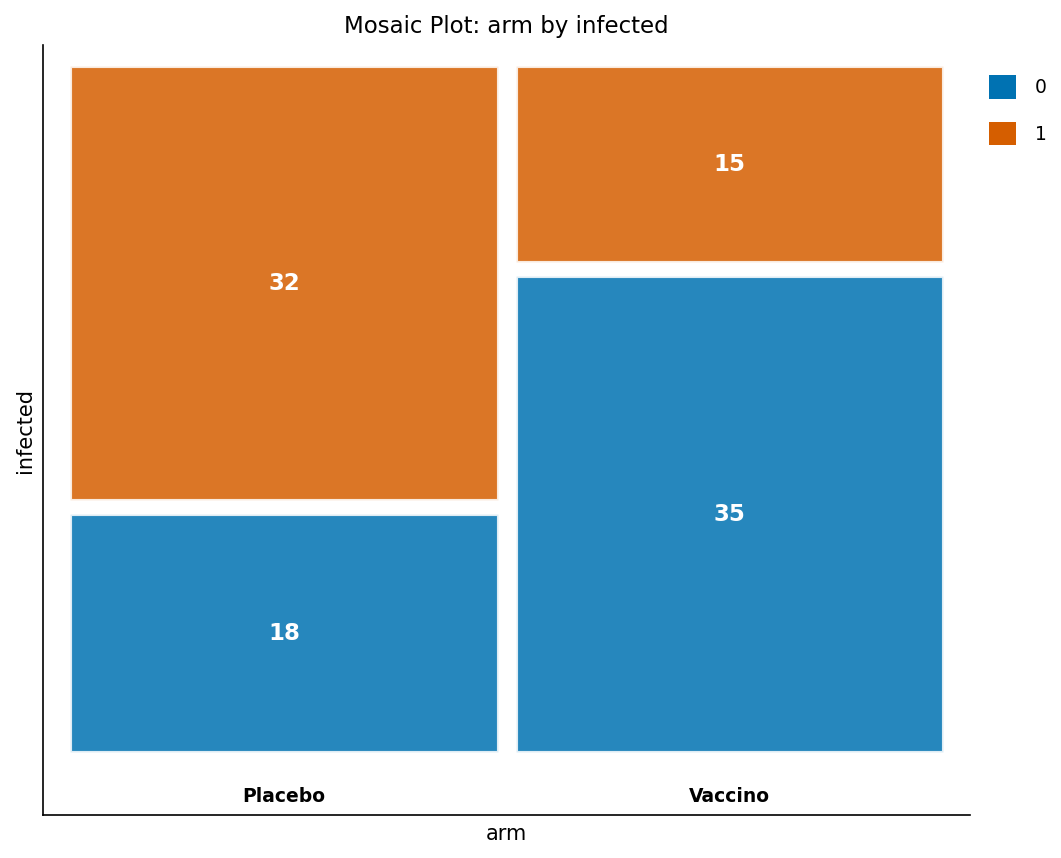

In [2]:
TITOLO "Infezione per braccio di trattamento";
PROCEDURA FREQUENZE DATI=trial;
    TABLES arm*infected / chisq relrisk riskdiff nocol nopercent;
    ETICHETTA arm="Braccio di trattamento" infected="Infettato (1=sì)";
ESEGUIRE;
TITOLO;

## 3. Tempo-persona e conteggi degli eventi per braccio

Prima di fidarci della tabella due-per-due grezza quantifichiamo lo squilibrio del follow-up. `PROC MEANS` riporta i giorni di follow-up totali e medi più il conteggio delle infezioni in ciascun braccio. Se il braccio vaccino accumula *più* tempo-persona (meno eventi precoci), la proporzione grezza sottostima l'efficacia — che è esattamente il motivo per cui passiamo a un modello tempo-evento successivamente.

In [3]:
TITOLO "Follow-up ed eventi per braccio";
PROCEDURA MEDIE DATI=trial n sum mean maxdec=2;
    CLASSE arm;
    VARIABILE fu_days infected;
    ETICHETTA arm="Braccio di trattamento" fu_days="Giorni di follow-up" infected="Infettato (1=sì)";
ESEGUIRE;
TITOLO;

                                            Follow-up ed eventi per braccio                                             

                                                  The MEANS Procedure

                                    Analysis Variable : fu_days Giorni di follow-up

        Braccio di trattamento          N Obs            Sum           Mean
        -------------------------------------------------------------------
        Placebo                            50       14552.00         291.04
        Vaccino                            50       19438.00         388.76
        -------------------------------------------------------------------

                                     Analysis Variable : infected Infettato (1=sì)

        Braccio di trattamento          N Obs            Sum           Mean
        -------------------------------------------------------------------
        Placebo                            50          32.00           0.64
        Vaccino              


NOTE: Option TITLE changed to Follow-up ed eventi per braccio.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. Curve di Kaplan-Meier e test log-rank

`PROC LIFETEST` stima la funzione di sopravvivenza product-limit (Kaplan-Meier) — qui, la probabilità di rimanere liberi da infezione nel tempo — separatamente per ciascun braccio. `STRATA arm / test=(logrank wilcoxon)` richiede i due test di omogeneità standard: il test **log-rank** pesa tutti i tempi di evento in modo uguale (più potente sotto rischi proporzionali), mentre **Wilcoxon** dà più peso agli eventi precoci. L'accordo tra loro sostiene l'assunzione dei rischi proporzionali su cui si baserà il modello di Cox. `ATRISK` annota il numero ancora a rischio.

                                   Curve di Kaplan-Meier e test log-rank per braccio                                    

    The LIFETEST Procedure    

                             N
--------------------  --------
Total                      100
Event                       47
Censored                    53
Median Survival Time  427.5000

Stratum: Braccio di trattamento = Placebo

                             N
--------------------  --------
Total                       50
Event                       32
Censored                    18
Median Survival Time  324.0000

               Product-Limit Survival Estimates                

    Time  Survival  Std Error  Number at Risk  Number of Events
--------  --------  ---------  --------------  ----------------
  9.0000    0.9800     0.0198              50                 1
 17.0000    0.9600     0.0277              49                 1
 23.0000    0.9400     0.0336              48                 1
 26.0000    0.9200     0.0384              4


NOTE: Option TITLE changed to Curve di Kaplan-Meier e test log-rank per braccio.
NOTE: PROC LIFETEST data=trial

NOTE: Using Python lifelines version 0.30.3
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


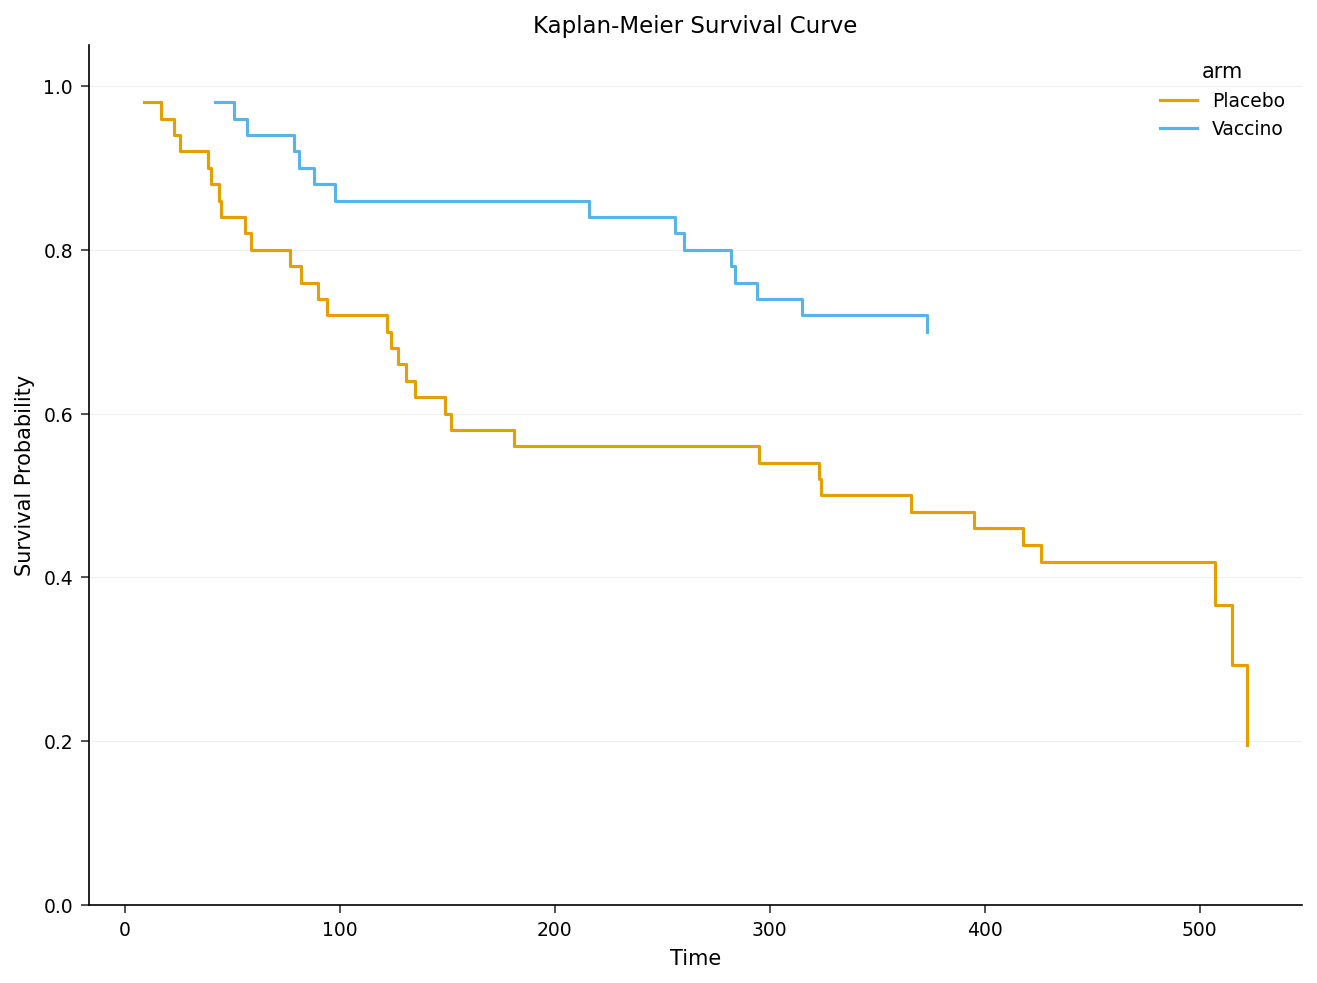

In [4]:
TITOLO "Curve di Kaplan-Meier e test log-rank per braccio";
PROCEDURA LIFETEST DATI=trial PLOTS=SURVIVAL atrisk;
    TIME fu_days*infected(0);
    STRATA arm / TEST=(logrank WILCOXON);
    ETICHETTA arm="Braccio di trattamento" fu_days="Giorni di follow-up";
ESEGUIRE;
TITOLO;

## 5. Modello di Cox aggiustato ed efficacia del vaccino

Il modello di Cox a rischi proporzionali fornisce l'hazard ratio **aggiustato**, controllando per età, sesso e rischio di esposizione al basale. `CLASS arm(ref='Placebo') sex(ref='M') / param=ref` imposta la codifica di riferimento così che il coefficiente `ARM` sia il logaritmo dell'hazard ratio di vaccino vs. placebo. `TIES=EFRON` è il metodo raccomandato per la gestione dei legami; `RL` stampa i limiti di confidenza dell'hazard ratio. Le istruzioni `HAZARDRATIO` riportano il contrasto tra bracci (CL di Wald) e l'effetto dell'età per incremento di 10 anni.

**L'efficacia del vaccino si legge direttamente come `VE = 1 - HR` per il termine del braccio**, e il limite di confidenza superiore dell'HR corrisponde al limite inferiore di efficacia da cui dipendono le decisioni di licenza.

In [5]:
TITOLO "Modello di Cox: efficacia del vaccino aggiustata";
PROCEDURA PHREG DATI=trial;
    CLASSE arm(REF='Placebo') sex(REF='M') / PARAM=REF;
    MODELLO fu_days*infected(0) = arm AGE sex baseline_risk / TIES=efron rl;
    hazardratio "Vaccino vs Placebo" arm / cl=wald;
    hazardratio AGE / units=10;
    ETICHETTA arm="Braccio di trattamento" AGE="Età" sex="Sesso" baseline_risk="Rischio di base (alta esposizione)" fu_days="Giorni di follow-up";
ESEGUIRE;

                                    Modello di Cox: efficacia del vaccino aggiustata                                    

        The PHREG Procedure        

Criterion                     Value
----------------------  -----------
Number of Observations          100
Number of Events                 47
-2 LOG L                    368.882
Ties Handling                 efron
Convergence Status      0 Converged

      Testing Global Null Hypothesis: BETA=0      

Test              Chi-Square        DF  Pr > ChiSq
----------------  ----------  --------  ----------
Likelihood Ratio     29.0183         4      <.0001
Wald                 28.4562         4      <.0001
Score (Log-Rank)     30.6491         4      <.0001

                                                Analysis of Maximum Likelihood Estimates                                                

Parameter                                 DF  Estimate  Standard Error  Chi-Square  Pr > ChiSq  Hazard Ratio  95% Lower CL  95% Upper CL
-----


NOTE: Option TITLE changed to Modello di Cox: efficacia del vaccino aggiustata.
NOTE: PROC PHREG data=trial

NOTE: PROC PHREG spec written to: ./ods_output/phreg_basic.spec.json
NOTE: PROC PHREG using Python wrapper


## Interpretazione

I tre livelli triangolano verso un'unica conclusione di efficacia:

- **Tasso di attacco grezzo (PROC FREQ).** La proporzione di infezione è del **64% nel placebo (32/50) contro il 30% nel vaccino (15/50)** — una differenza di rischio di **-0.34** (IC al 95% da -0.524 a -0.156) e un odds ratio di **0.241** (IC al 95% da 0.105 a 0.556). Il test chi-quadro rifiuta l'indipendenza (χ² = 11.60, p = 0.0007). Questo è il segnale a colpo d'occhio che un revisore si aspetta per primo — ma ignora il follow-up scaglionato e non uniforme.

- **Tempo-persona (PROC MEANS).** Il follow-up medio è più lungo nel braccio vaccino (**388.8 vs 291.0 giorni**) proprio perché meno partecipanti escono precocemente per infezione (15 eventi vaccino vs 32 placebo). Ciò conferma che la proporzione grezza è una visione conservativa, confusa dal follow-up, e giustifica l'analisi tempo-evento.

- **Kaplan-Meier + log-rank (PROC LIFETEST).** Le curve di sopravvivenza si separano chiaramente — il placebo raggiunge un **tempo mediano libero da infezione di 324 giorni mentre la mediana del vaccino non viene raggiunta** (solo 15 dei 50 vaccinati sono mai stati infettati). Entrambi i test di omogeneità rifiutano l'uguaglianza: **log-rank χ² = 11.25 (p = 0.0008)** e **Wilcoxon χ² = 9.11 (p = 0.0025)**. Il loro accordo sostiene l'assunzione dei rischi proporzionali alla base del modello di Cox.

- **Modello di Cox aggiustato (PROC PHREG).** Dopo aver aggiustato per età, sesso e rischio di esposizione al basale, l'hazard ratio vaccino-vs-placebo è **0.369** con un IC al 95% di **(0.198, 0.687)** interamente al di sotto di 1 (p = 0.0017), dando una **efficacia del vaccino stimata di circa il 63%** (`VE = 1 - 0.369`). Il limite inferiore di efficacia (dal limite di confidenza superiore dell'HR di 0.687) è vicino al **31%**, al margine della soglia convenzionale di licenza del 30-50% — ampio, come previsto per uno studio di 100 soggetti. L'occupazione ad alta esposizione triplica all'incirca l'hazard di infezione (**HR = 3.47**, IC al 95% 1.90-6.35, p < .0001), confermando che l'aggiustamento per le covariate è giustificato; l'età (HR = 1.022 per anno, p = 0.059) e il sesso femminile (HR = 0.541, p = 0.064) portano effetti al limite che non raggiungono la significatività al livello 0.05. L'ipotesi nulla globale è rifiutata (rapporto di verosimiglianza χ² = 29.0, p < .0001).

**Conclusione.** Poiché la tabella due-per-due grezza, le curve di Kaplan-Meier separate e la stima di Cox aggiustata puntano tutte nella stessa direzione con intervalli di confidenza che escludono l'assenza di effetto, lo studio sostiene un segnale di efficacia — anche se gli ampi limiti di confidenza riflettono il piccolo campione. In una vera sottomissione, la stima di Cox `1 - HR` e il suo intervallo di confidenza — non la proporzione grezza — sarebbero l'endpoint primario, con gli output di FREQ e LIFETEST che servono come conferma descrittiva e non parametrica di supporto che un Comitato di Monitoraggio della Sicurezza dei Dati esamina insieme ad essa.